# 04 — Sentinel-1 Preprocessing & SAR Feature Engineering

**Author:** Florian Klaver

**Prerequisite:** Run notebook 03 first and download all `S1_YYYYMMDD.tif` files from Google Drive
folder `satellite-mowing-s1/` into `data/Sentinel_S1/`.

---

## What this notebook does

1. **Verify** downloaded S1 files: CRS, resolution, band layout, dB value ranges.
2. **Alignment check** — confirm S1 and S2 share the same pixel grid. Reproject S1 to match
   the S2 reference grid if needed (bilinear, EPSG:2056, 10 m).
3. **Feature computation loop** — for each mowing event with a full S1 triplet, compute 6 SAR
   features and save as a 6-band GeoTIFF.
4. **Coverage summary** — report how many of the 92 events are ready for fusion training.

### The 6 SAR features

| Feature | Formula | Physical meaning |
|---|---|---|
| `vv_after` | VV (dB) of the AFTER image | Surface roughness / soil state |
| `vh_after` | VH (dB) of the AFTER image | Canopy volume scattering |
| `cr_after` | VH − VV (dB) | Cross-ratio removes look-angle bias |
| `vv_diff` | VV_after − VV_before_near | Change in surface scattering |
| `vh_diff` | VH_after − VH_before_near | Change in canopy scattering (key mowing signal) |
| `cr_diff` | CR_after − CR_before_near | Level-independent mowing signal |

After mowing: VH drops (canopy collapses), so `vh_diff` and `cr_diff` are strongly negative.

**Output:** `data/features_s1/<match_id>_s1_features.tif` — 6-band float32, same grid as S2 tiles.

---
## 1. Setup

In [31]:
import sys
import os
import glob
import numpy as np
import pandas as pd
import rasterio
from rasterio.crs import CRS
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join('..', 'src'))
from sar_features import (
    load_s1_bands, compute_sar_features, align_s1_to_reference, save_s1_features
)

S1_DIR          = r'..\\data\\Sentinel_S1'
S2_DIR          = r'..\\data\\Sentinel_CH'
FEATURES_S1_DIR = r'..\\data\\features_s1'
TEMPORAL_MATCHES = r'..\\data\\temporal_matches.csv'
EVENT_COVERAGE   = r'..\\data\\s1_event_coverage.csv'
MIN_FEATURE_VALID_PCT = 10.0  # skip feature rasters with too little finite coverage

os.makedirs(FEATURES_S1_DIR, exist_ok=True)

# Use the first available S2 tile as the alignment reference
s2_files = sorted(glob.glob(os.path.join(S2_DIR, '*.tif')))
S2_REFERENCE = s2_files[0]

print(f'S2 reference tile: {os.path.basename(S2_REFERENCE)}')
print(f'S1 files found:    {len(glob.glob(os.path.join(S1_DIR, "S1_*.tif")))}')

S2 reference tile: 2019-03-01.tif
S1 files found:    94


---
## 2. Verify S1 Files

In [32]:
s1_files = sorted(glob.glob(os.path.join(S1_DIR, 'S1_*.tif')))
print(f'S1 GeoTIFFs on disk: {len(s1_files)}')

if len(s1_files) == 0:
    print('\nNo S1 files found. Download from Google Drive first:')
    print('  Drive folder: satellite-mowing-s1/')
    print('  Local target: data/Sentinel_S1/')
else:
    # Spot-check first file
    sample = s1_files[0]
    with rasterio.open(sample) as src:
        print(f'\n--- Spot check: {os.path.basename(sample)} ---')
        print(f'CRS:        {src.crs}  (expected: EPSG:2056)')
        print(f'Resolution: {src.res}  (expected: (10.0, 10.0))')
        print(f'Bands:      {src.count}  (expected: 2 — Band1=VV, Band2=VH)')
        print(f'Shape:      {src.height} × {src.width} px')
        vv = src.read(1).astype(float)
        vh = src.read(2).astype(float)
        vv[vv < -35] = np.nan
        vh[vh < -35] = np.nan
        print(f'VV range:   {np.nanmin(vv):.1f} to {np.nanmax(vv):.1f} dB')
        print(f'VH range:   {np.nanmin(vh):.1f} to {np.nanmax(vh):.1f} dB')
        print()
        print('Expected ranges over airport grassland:')
        print('  VV: ~-10 to -5 dB  (surface/soil scattering)')
        print('  VH: ~-20 to -12 dB (canopy volume scattering, always lower than VV)')

S1 GeoTIFFs on disk: 94

--- Spot check: S1_20190430.tif ---
CRS:        EPSG:2056  (expected: EPSG:2056)
Resolution: (10.0, 10.0)  (expected: (10.0, 10.0))
Bands:      2  (expected: 2 — Band1=VV, Band2=VH)
Shape:      561 × 398 px
VV range:   -23.3 to 21.1 dB
VH range:   -30.7 to 8.8 dB

Expected ranges over airport grassland:
  VV: ~-10 to -5 dB  (surface/soil scattering)
  VH: ~-20 to -12 dB (canopy volume scattering, always lower than VV)


---
## 3. Alignment Check: S1 vs. S2 Grid

Both S1 and S2 are exported at 10 m in EPSG:2056, but the pixel grid origins may differ slightly.
We check whether the transforms match. If not, `align_s1_to_reference()` reprojects S1 to the
exact S2 grid so pixel lookups in notebook 05 are accurate.

In [33]:
if len(s1_files) == 0:
    print('No S1 files to check.')
else:
    with rasterio.open(s1_files[0]) as s1:
        s1_transform = s1.transform
        s1_crs       = s1.crs
        s1_shape     = (s1.height, s1.width)

    with rasterio.open(S2_REFERENCE) as s2:
        s2_transform = s2.transform
        s2_crs       = s2.crs
        s2_shape     = (s2.height, s2.width)

    print('=== Grid Comparison ===')
    print(f'S1 CRS:       {s1_crs}')
    print(f'S2 CRS:       {s2_crs}')
    print(f'S1 transform: {s1_transform}')
    print(f'S2 transform: {s2_transform}')
    print(f'S1 shape:     {s1_shape}')
    print(f'S2 shape:     {s2_shape}')

    crs_match       = s1_crs == s2_crs
    transform_match = s1_transform == s2_transform
    shape_match     = s1_shape == s2_shape

    print()
    print(f'CRS match:       {crs_match}')
    print(f'Transform match: {transform_match}')
    print(f'Shape match:     {shape_match}')

    if crs_match and transform_match and shape_match:
        print('\nGrids are identical — no reprojection needed. align_s1_to_reference() will be skipped.')
        NEEDS_ALIGNMENT = False
    else:
        print('\nGrids differ — align_s1_to_reference() will reproject each S1 image to match S2.')
        NEEDS_ALIGNMENT = True

=== Grid Comparison ===
S1 CRS:       EPSG:2056
S2 CRS:       EPSG:2056
S1 transform: | 10.00, 0.00, 2681930.00|
| 0.00,-10.00, 1260390.00|
| 0.00, 0.00, 1.00|
S2 transform: | 10.00, 0.00, 2682012.93|
| 0.00,-10.00, 1260380.67|
| 0.00, 0.00, 1.00|
S1 shape:     (561, 398)
S2 shape:     (559, 381)

CRS match:       True
Transform match: False
Shape match:     False

Grids differ — align_s1_to_reference() will reproject each S1 image to match S2.


---
## 4. Load Event Metadata

Join `temporal_matches.csv` (which defines `match_id`) with `s1_event_coverage.csv`
(which lists the matched S1 dates per event). We process only events with `full_triplet_ok=True`.

In [34]:
# match_id = 0-based integer row index in temporal_matches.csv
matches_df = pd.read_csv(TEMPORAL_MATCHES)
matches_df['match_id'] = matches_df.index

coverage_df = pd.read_csv(EVENT_COVERAGE)

# Join on event_date_str to attach match_id and S2 filenames
events = coverage_df.merge(
    matches_df[['event_date_str', 'match_id', 'before_far_file', 'before_near_file', 'after_file']],
    on='event_date_str', how='left'
)

full_triplet = events[events['full_triplet_ok'] == True].copy()

print(f'Total events:              {len(events)}')
print(f'With full S1 triplet:      {len(full_triplet)}')
print(f'Missing S1 (skipped):      {len(events) - len(full_triplet)}')
print()
print('Sample rows:')
print(full_triplet[['event_date_str', 'match_id', 'bn_s1', 'af_s1']].head())

Total events:              92
With full S1 triplet:      92
Missing S1 (skipped):      0

Sample rows:
   event_date_str  match_id       bn_s1       af_s1
0        20190509         0  2019-05-06  2019-05-12
1        20190516         1  2019-05-12  2019-05-18
2        20190523         2  2019-05-19  2019-05-25
3        20190530         3  2019-05-25  2019-05-31
4        20190531         4  2019-05-25  2019-05-31


---
## 5. SAR Feature Computation Loop

For each event with a full S1 triplet:
1. Identify the `before_near` and `after` S1 files from the matched dates
2. Load bands (already in dB from GEE export)
3. Align to S2 reference grid if needed
4. Compute 6 features via `compute_sar_features()`
5. Save 6-band GeoTIFF to `data/features_s1/<match_id>_s1_features.tif`

In [35]:
def s1_date_to_path(s1_date_value):
    """Convert s1_date column value (Timestamp or string) to S1_YYYYMMDD.tif path."""
    ts = pd.Timestamp(s1_date_value)
    filename = f'S1_{ts.strftime("%Y%m%d")}.tif'
    return os.path.join(S1_DIR, filename)


saved   = 0
skipped = 0
errors  = []

for _, row in full_triplet.iterrows():
    match_id  = int(row['match_id'])
    out_path  = os.path.join(FEATURES_S1_DIR, f'{match_id}_s1_features.tif')

    # Skip if already computed
    if os.path.exists(out_path):
        skipped += 1
        continue

    bn_path = s1_date_to_path(row['bn_s1'])  # before_near S1
    af_path = s1_date_to_path(row['af_s1'])  # after S1

    if not os.path.exists(bn_path) or not os.path.exists(af_path):
        errors.append({'match_id': match_id, 'event': row['event_date_str'],
                       'missing': [p for p in [bn_path, af_path] if not os.path.exists(p)]})
        continue

    try:
        if NEEDS_ALIGNMENT:
            bn_vv, bn_vh, ref_profile = align_s1_to_reference(bn_path, S2_REFERENCE)
            af_vv, af_vh, _           = align_s1_to_reference(af_path, S2_REFERENCE)
        else:
            bn_vv, bn_vh, ref_profile = load_s1_bands(bn_path)
            af_vv, af_vh, _           = load_s1_bands(af_path)

        features = compute_sar_features(bn_vv, bn_vh, af_vv, af_vh)

        valid_pct = (np.isfinite(features['vv_after']).sum() / features['vv_after'].size) * 100.0
        if valid_pct < MIN_FEATURE_VALID_PCT:
            errors.append({
                'match_id': match_id,
                'event': row['event_date_str'],
                'error': f'vv_after valid coverage too low: {valid_pct:.1f}% (< {MIN_FEATURE_VALID_PCT:.1f}%)'
            })
            continue

        save_s1_features(features, ref_profile, out_path)
        saved += 1

    except Exception as e:
        errors.append({'match_id': match_id, 'event': row['event_date_str'], 'error': str(e)})

print(f'=== Feature Computation Summary ===')
print(f'Saved:   {saved}')
print(f'Skipped (already on disk): {skipped}')
print(f'Errors:  {len(errors)}')
if errors:
    for e in errors:
        print(f'  match_id={e["match_id"]} ({e["event"]}): {e.get("error", e.get("missing"))}')

=== Feature Computation Summary ===
Saved:   92
Skipped (already on disk): 0
Errors:  0


---
## 6. Verify Output Files

In [36]:
feature_files = sorted(glob.glob(os.path.join(FEATURES_S1_DIR, '*_s1_features.tif')))
print(f'Feature files on disk: {len(feature_files)}')
print(f'Expected (full triplet events): {len(full_triplet)}')

if feature_files:
    # Spot-check first file
    sample_f = feature_files[0]
    with rasterio.open(sample_f) as src:
        print(f'\n--- Spot check: {os.path.basename(sample_f)} ---')
        print(f'CRS:    {src.crs}  (expected: EPSG:2056)')
        print(f'Res:    {src.res}  (expected: ~(10.0, 10.0))')
        print(f'Bands:  {src.count}  (expected: 6)')
        print(f'Shape:  {src.height} × {src.width}')
        band_names = ['vv_after', 'vh_after', 'cr_after', 'vv_diff', 'vh_diff', 'cr_diff']
        print()
        for i, name in enumerate(band_names, 1):
            arr = src.read(i).astype(float)
            arr[arr < -60] = np.nan  # catch any extreme outliers
            print(f'  Band {i} ({name}): {np.nanmin(arr):.2f} to {np.nanmax(arr):.2f} dB')
        print()
        b1 = src.read(1).astype(float)
        valid = (~np.isnan(b1)).sum()
        total = b1.size
        pct   = valid / total * 100
        print(f'  Valid (non-NaN) pixels band 1: {valid:,} / {total:,} ({pct:.1f}%)')
        if pct < 50:
            print('  ⚠ WARNING: <50% valid pixels — check S1 export AOI in notebook 03')
        else:
            print('  ✓ Coverage OK')

Feature files on disk: 92
Expected (full triplet events): 92

--- Spot check: 0_s1_features.tif ---
CRS:    EPSG:2056  (expected: EPSG:2056)
Res:    (10.004343069802987, 10.004343069802987)  (expected: ~(10.0, 10.0))
Bands:  6  (expected: 6)
Shape:  559 × 381

  Band 1 (vv_after): -23.88 to 19.65 dB
  Band 2 (vh_after): -30.30 to 8.09 dB
  Band 3 (cr_after): -29.96 to 2.60 dB
  Band 4 (vv_diff): -14.69 to 17.61 dB
  Band 5 (vh_diff): -9.59 to 12.95 dB
  Band 6 (cr_diff): -13.33 to 15.46 dB

  Valid (non-NaN) pixels band 1: 211,329 / 212,979 (99.2%)
  ✓ Coverage OK


---
## 7. Quick Visual Sanity Check

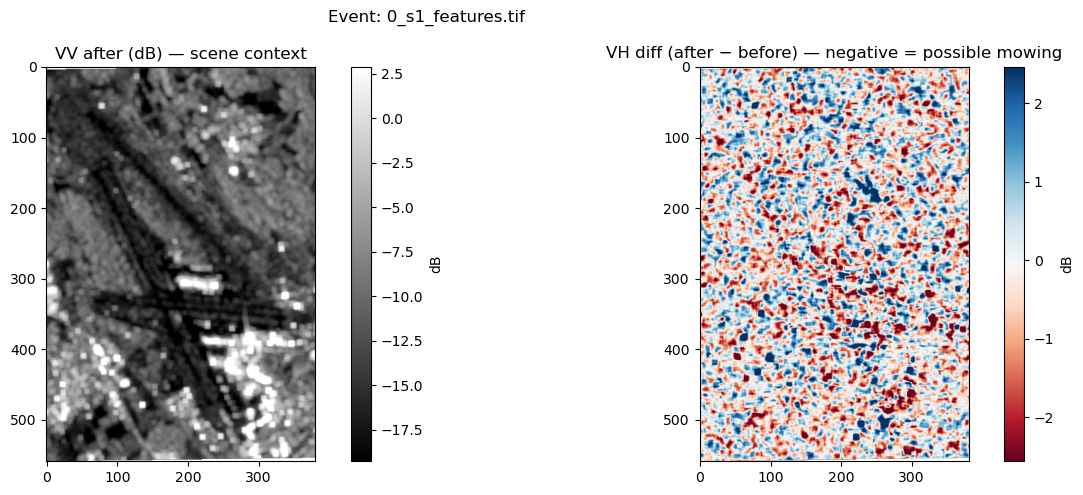


Interpretation:
  Blue (negative VH diff) → backscatter decreased → candidate mowing areas
  Red  (positive VH diff) → backscatter increased → growth / moisture change


In [37]:
if len(feature_files) == 0:
    print('No feature files to visualise.')
else:
    # Show vh_diff (band 5) for the first event — should look like a change map
    with rasterio.open(feature_files[0]) as src:
        vh_diff = src.read(5).astype(float)  # band 5 = vh_diff
        vv_after = src.read(1).astype(float)  # band 1 = vv_after (background)

    vh_diff[vh_diff < -60] = np.nan
    vv_after[vv_after < -35] = np.nan

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    im0 = axes[0].imshow(vv_after, cmap='gray',
                          vmin=np.nanpercentile(vv_after, 2),
                          vmax=np.nanpercentile(vv_after, 98))
    axes[0].set_title('VV after (dB) — scene context')
    plt.colorbar(im0, ax=axes[0], label='dB')

    im1 = axes[1].imshow(vh_diff, cmap='RdBu',
                          vmin=np.nanpercentile(vh_diff, 2),
                          vmax=np.nanpercentile(vh_diff, 98))
    axes[1].set_title('VH diff (after − before) — negative = possible mowing')
    plt.colorbar(im1, ax=axes[1], label='dB')

    plt.suptitle(f'Event: {os.path.basename(feature_files[0])}')
    plt.tight_layout()
    plt.show()

    print('\nInterpretation:')
    print('  Blue (negative VH diff) → backscatter decreased → candidate mowing areas')
    print('  Red  (positive VH diff) → backscatter increased → growth / moisture change')

---
## 8. Final Coverage Summary

Report how many events are now fully ready for fusion training in notebook 05.

In [38]:
ready_ids = {
    int(os.path.basename(f).split('_')[0])
    for f in glob.glob(os.path.join(FEATURES_S1_DIR, '*_s1_features.tif'))
}

total_events      = len(matches_df)
full_triplet_n    = len(full_triplet)
features_computed = len(ready_ids)
no_s1_coverage    = total_events - full_triplet_n
compute_failed    = full_triplet_n - features_computed

print('=== Final Coverage for Fusion Training ===')
print(f'Total events:                    {total_events}')
print(f'  → S1 triplet available:        {full_triplet_n}')
print(f'     → SAR features computed:    {features_computed}  ✓ ready for notebook 05')
print(f'     → Compute failed/missing:   {compute_failed}')
print(f'  → No S1 coverage (dropped):    {no_s1_coverage}')
print()
pct = features_computed / total_events * 100
print(f'Fusion-ready events: {features_computed}/{total_events} ({pct:.0f}%)')

if pct < 70:
    print('\nWarning: Less than 70% coverage. Check S1 download completeness and ±3-day tolerance.')
else:
    print('\nCoverage is sufficient for fusion training. Proceed to notebook 05.')

=== Final Coverage for Fusion Training ===
Total events:                    92
  → S1 triplet available:        92
     → SAR features computed:    92  ✓ ready for notebook 05
     → Compute failed/missing:   0
  → No S1 coverage (dropped):    0

Fusion-ready events: 92/92 (100%)

Coverage is sufficient for fusion training. Proceed to notebook 05.


---
## Summary

**What this notebook produced:**
- `data/features_s1/<match_id>_s1_features.tif` for each covered event
- 6-band float32 GeoTIFF, EPSG:2056, 10 m, same grid as S2 tiles
- Band order: `vv_after`, `vh_after`, `cr_after`, `vv_diff`, `vh_diff`, `cr_diff`

**Next step → notebook 05:** Merge these S1 feature rasters with the existing S2 pixel samples
from `data/training_samples_all_indices.csv` to produce `data/training_samples_fusion.csv`
(26 features per pixel: 20 S2 + 6 SAR).

# What i should test based on https://www.mdpi.com/2072-4292/13/3/348
Coherence jump. After mowing the coherence values should jump from low to higher values due to reduction of biomass

https://ieeexplore.ieee.org/abstract/document/7302559
"For vegetation height limited to the range between 0 and 1 m, a very strong correlation between the grass height and the linearised temporal coherence was found, with a coefficient r = 0.81. No significant correlation was found between the backscattering coefficient and the wet above-ground biomass as well as the height of grass."
HH polarization as signal


"Results showed that after a mowing event, median VH (vertical transmit, horizontal receive) and VV (vertical transmit, vertical receive) polarisation coherence values were statistically significantly higher than those from before the event. The coherence tended to stay higher, even 24 to 36 days after a mowing event. Precipitation caused the coherence to decrease, impeding the detection of a mowing even"
